## EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import learning_curve
from sklearn.tree import export_graphviz
import graphviz
from xgboost import XGBRegressor

In [2]:
data = pd.read_csv('indonesia_earthquake.csv')

In [3]:
data.head()

,id,eventID,date,time,latitude,longitude,magnitude,mag_type,depth,phasecount,azimuth_gap,location
0,0,bmg2008vkye,11/1/2008,31:25.1,-0.604440,98.895531,2.989742,MLv,20,6.0,146.70738,"Southern Sumatra, Indonesia"
1,1,bmg2008vlag,11/1/2008,34:29.7,-6.611860,129.387220,5.507549,mb,30,62.0,45.46764,Banda Sea
2,2,bmg2008vlaj,11/1/2008,38:14.8,-3.650586,127.990680,3.539674,MLv,5,4.0,331.97404,"Seram, Indonesia"
3,3,bmg2008vlbt,11/1/2008,20:05.9,-4.198925,128.097000,2.424314,MLv,5,5.0,326.37993,Banda Sea
4,4,bmg2008vlcd,11/1/2008,32:18.8,-4.091891,128.200470,2.410045,MLv,10,5.0,314.65474,Banda Sea


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102515 entries, 0 to 102514
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           102515 non-null  int64  
 1   eventID      102515 non-null  object 
 2   date         102515 non-null  object 
 3   time         102515 non-null  object 
 4   latitude     102515 non-null  float64
 5   longitude    102515 non-null  float64
 6   magnitude    102003 non-null  float64
 7   mag_type     102003 non-null  object 
 8   depth        102515 non-null  int64  
 9   phasecount   102513 non-null  float64
 10  azimuth_gap  102511 non-null  float64
 11  location     102512 non-null  object 
dtypes: float64(5), int64(2), object(5)
memory usage: 9.4+ MB


In [5]:
plt.figure(figsize=(12, 6))
sns.histplot(data['magnitude'], kde=True, color='skyblue')
plt.title('Distribusi Magnitude Gempa')
plt.xlabel('Magnitude')
plt.ylabel('Frekuensi')
plt.show()

NameError: name 'sns' is not defined

<Figure size 1200x600 with 0 Axes>

C:\Users\ricar\AppData\Local\Temp\ipykernel_7688\2576090870.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='mag_type', palette='Set2')


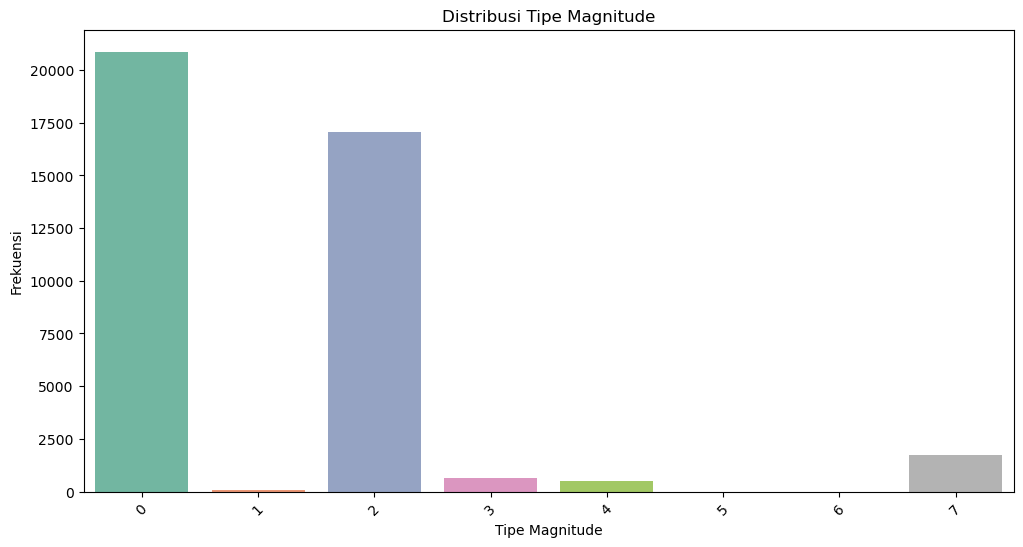

In [23]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='mag_type', palette='Set2')
plt.title('Distribusi Tipe Magnitude')
plt.xlabel('Tipe Magnitude')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45)
plt.show()

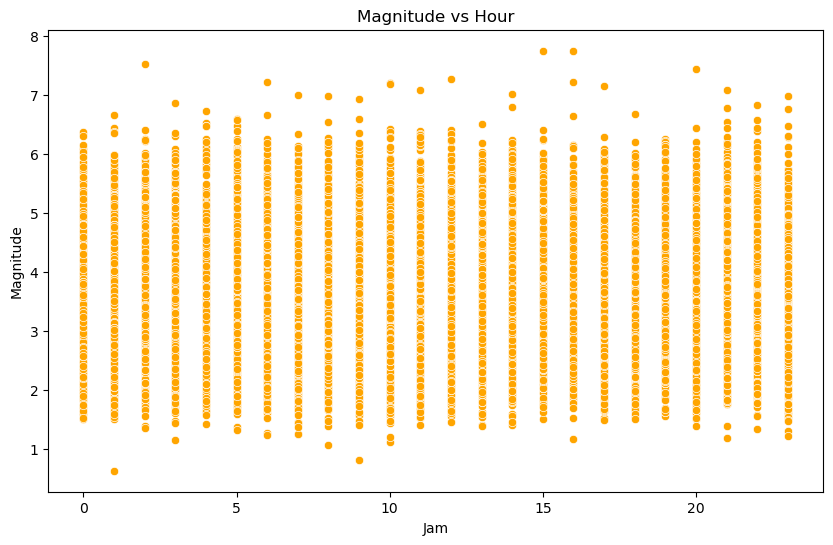

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='hour', y='magnitude', color='orange')
plt.title('Magnitude vs Hour')
plt.xlabel('Jam')
plt.ylabel('Magnitude')
plt.show()

C:\Users\ricar\AppData\Local\Temp\ipykernel_7688\2416908099.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='month', y='magnitude', palette='coolwarm')


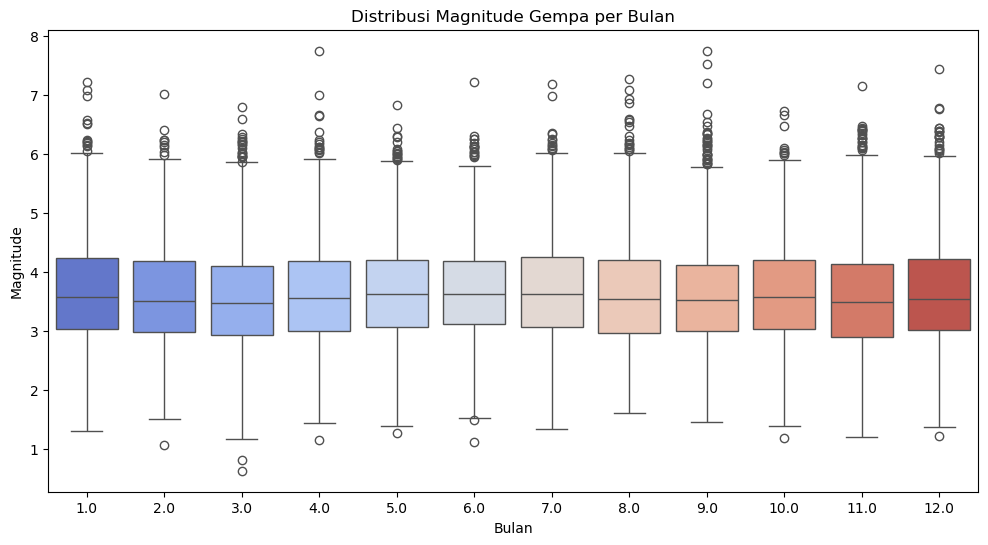

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='month', y='magnitude', palette='coolwarm')
plt.title('Distribusi Magnitude Gempa per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Magnitude')
plt.show()

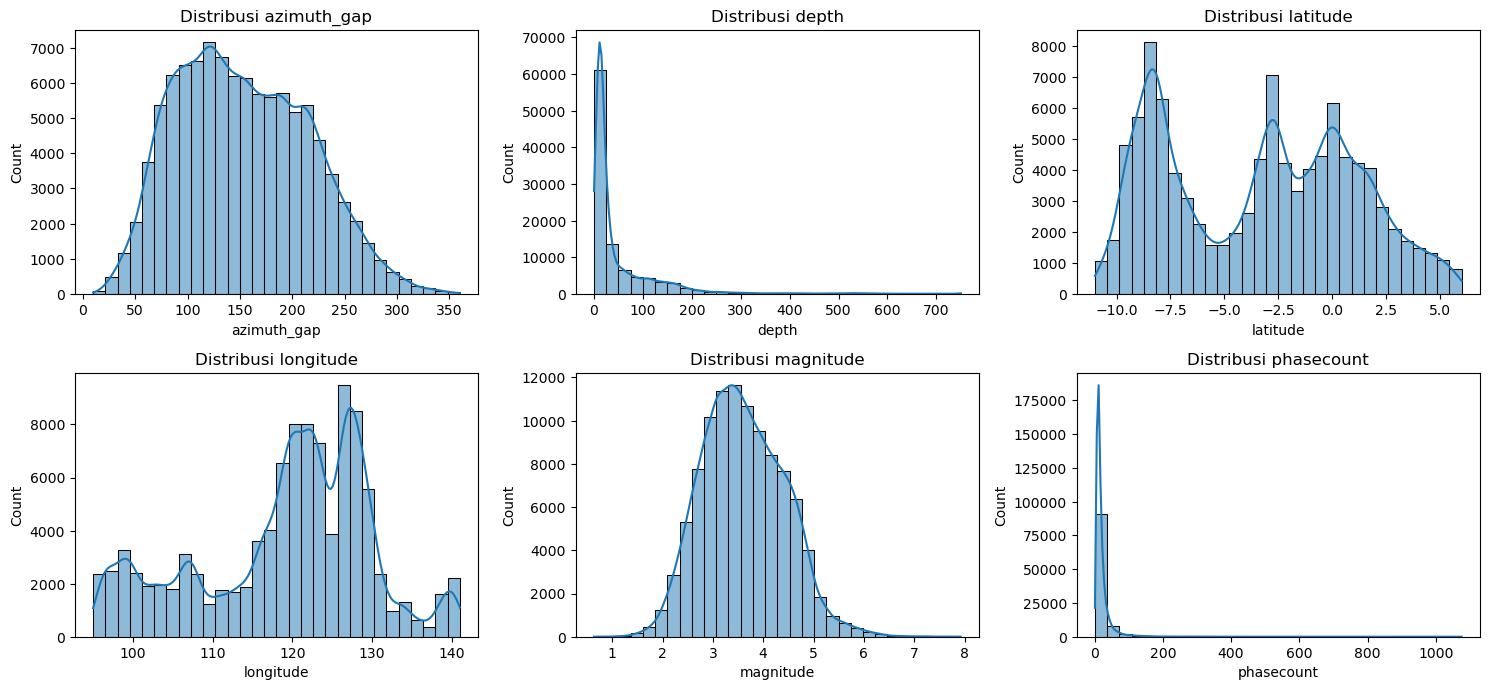

In [39]:
columns_to_exclude = ['id', 'eventID', 'date', 'time', 'location']
num_columns = data.select_dtypes(include=['number']).columns.difference(columns_to_exclude)

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

## PreProcessing

In [9]:
data = data.drop(columns=['id', 'eventID', 'date', 'time', 'datetime'])

In [10]:
data = data.dropna()

## Feature Engineering

In [6]:
data['datetime'] = pd.to_datetime(data['date'] + ' ' + data['time'], errors='coerce')

C:\Users\ricar\AppData\Local\Temp\ipykernel_40380\2174891566.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['datetime'] = pd.to_datetime(data['date'] + ' ' + data['time'], errors='coerce')


In [7]:
le_magtype = LabelEncoder()
data['mag_type'] = le_magtype.fit_transform(data['mag_type'])
le_location = LabelEncoder()
data['location'] = le_location.fit_transform(data['location'])

In [8]:
data['hour'] = data['datetime'].dt.hour
data['month'] = data['datetime'].dt.month
data['year'] = data['datetime'].dt.year

## MODELLING (60:40)

In [11]:
X = data.drop(columns=['magnitude'])
y = data['magnitude']

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

In [14]:
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}


In [15]:
rf = RandomForestRegressor(random_state=42)
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, 
                               n_iter=30, cv=3, verbose=1, random_state=42, n_jobs=-1)

rf_random.fit(X_train, y_train)
best_rf = rf_random.best_estimator_

xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

cv_rf_scores = cross_val_score(best_rf, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
cv_xgb_scores = cross_val_score(xgb_model, X_scaled, y, cv=5, scoring='neg_mean_squared_error')


Fitting 3 folds for each of 30 candidates, totalling 90 fits


In [16]:
y_pred_rf = best_rf.predict(X_test)

y_pred_xgb = xgb_model.predict(X_test)

## Evaluation

In [17]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f'Random Forest MSE: {mse_rf:.4f}, R2: {r2_rf:.4f}')
print(f'XGBoost       MSE: {mse_xgb:.4f}, R2: {r2_xgb:.4f}')

print(f'Cross-Validation MSE for RandomForest: {np.mean(cv_rf_scores):.4f}')
print(f'Cross-Validation MSE for XGBoost: {np.mean(cv_xgb_scores):.4f}')

Random Forest MSE: 0.1731, R2: 0.7415
XGBoost       MSE: 0.1737, R2: 0.7406
Cross-Validation MSE for RandomForest: -0.2559
Cross-Validation MSE for XGBoost: -0.2940


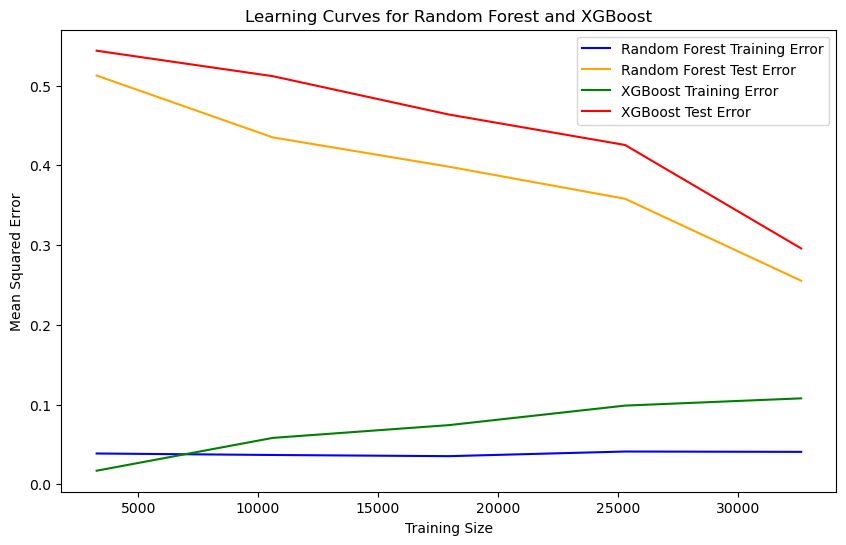

In [39]:
train_sizes, train_scores, test_scores = learning_curve(best_rf, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, -np.mean(train_scores, axis=1), label="Random Forest Training Error", color='blue')
plt.plot(train_sizes, -np.mean(test_scores, axis=1), label="Random Forest Test Error", color='orange')

train_sizes, train_scores, test_scores = learning_curve(xgb_model, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
plt.plot(train_sizes, -np.mean(train_scores, axis=1), label="XGBoost Training Error", color='green')
plt.plot(train_sizes, -np.mean(test_scores, axis=1), label="XGBoost Test Error", color='red')

plt.xlabel("Training Size")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curves for Random Forest and XGBoost")
plt.legend()
plt.show()

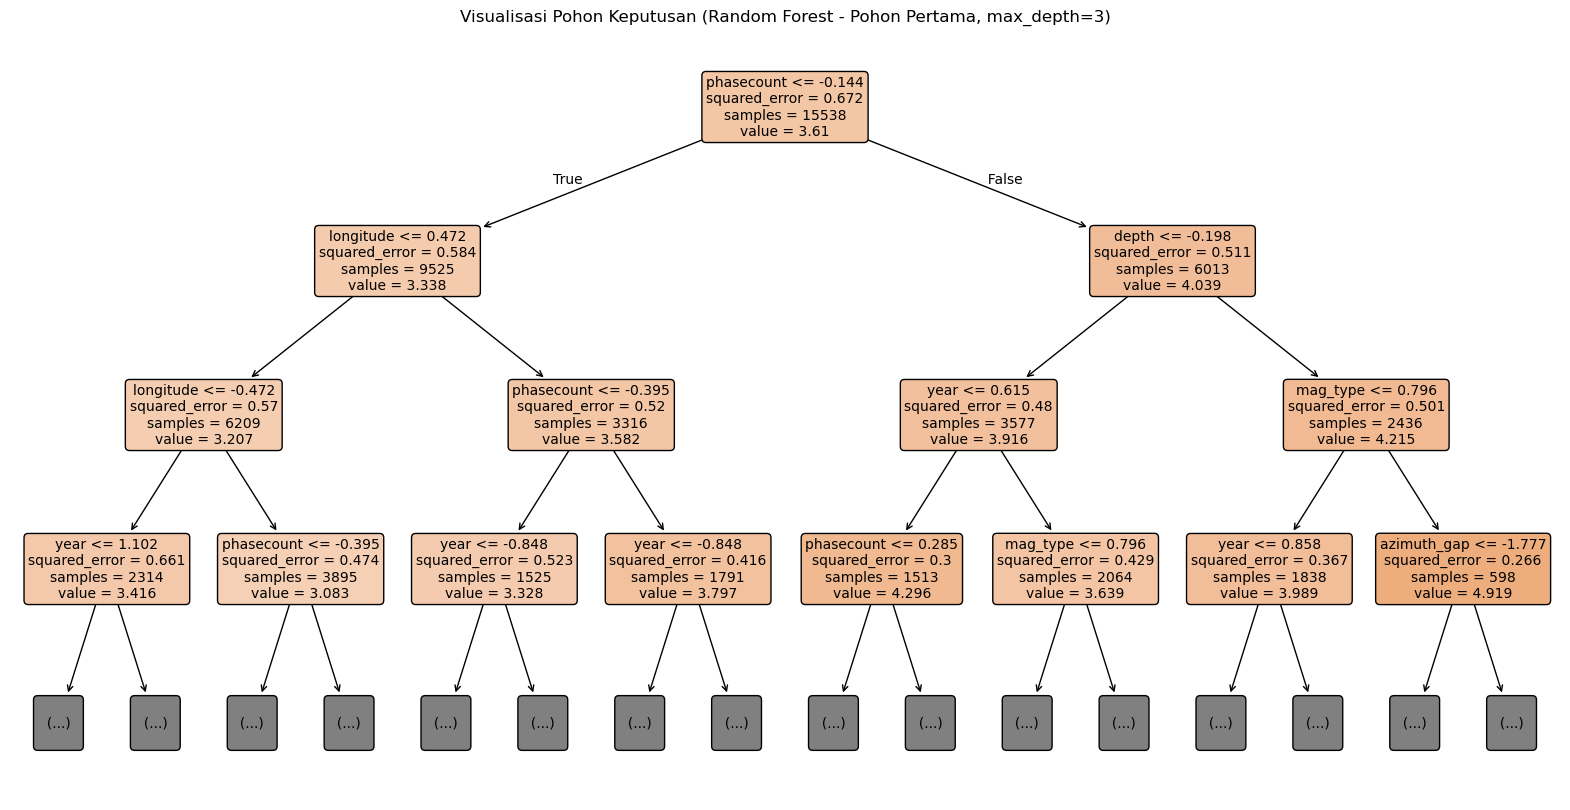

In [37]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    best_rf.estimators_[0],
    feature_names=X.columns,
    filled=True,
    rounded=True,
    max_depth=3, 
    fontsize=10
)
plt.title("Visualisasi Pohon Keputusan (Random Forest - Pohon Pertama, max_depth=3)")
plt.show()


## Modelling (80:20) / Tertinggi

In [23]:
X = data.drop(columns=['magnitude'])
y = data['magnitude']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [24]:
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [25]:
rf = RandomForestRegressor(random_state=42)
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, 
                               n_iter=30, cv=3, verbose=1, random_state=42, n_jobs=-1)
rf_random.fit(X_train_scaled, y_train)
best_rf = rf_random.best_estimator_

xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

y_pred_rf = best_rf.predict(X_test_scaled)
y_pred_xgb = xgb_model.predict(X_test_scaled)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


## Evaluation

In [26]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"Random Forest MSE: {mse_rf:.4f}, R2: {r2_rf:.4f}")
print(f"XGBoost MSE: {mse_xgb:.4f}, R2: {r2_xgb:.4f}")

cv_rf_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
cv_xgb_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

print(f'Cross-Validation MSE for RandomForest: {np.mean(cv_rf_scores):.4f}')
print(f'Cross-Validation MSE for XGBoost: {np.mean(cv_xgb_scores):.4f}')

Random Forest MSE: 0.1657, R2: 0.7522
XGBoost MSE: 0.1661, R2: 0.7515
Cross-Validation MSE for RandomForest: -0.1746
Cross-Validation MSE for XGBoost: -0.1751


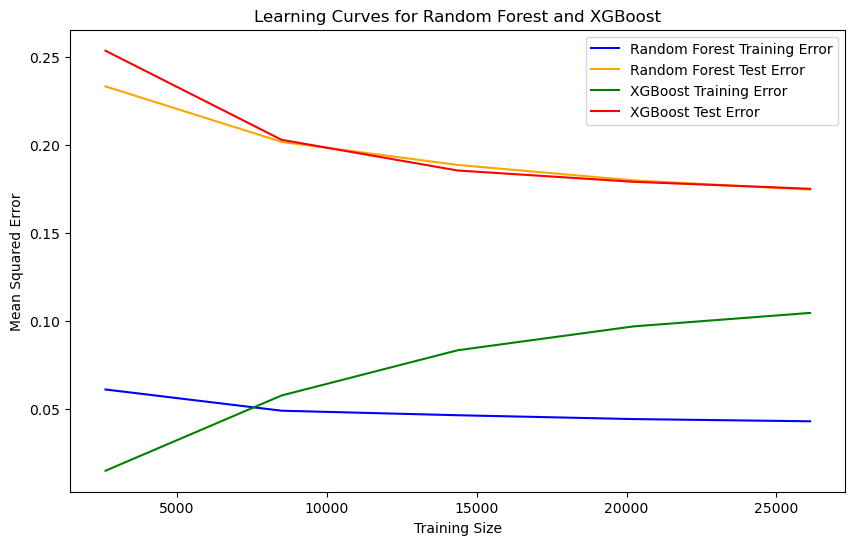

In [27]:
train_sizes, train_scores, test_scores = learning_curve(best_rf, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, -np.mean(train_scores, axis=1), label="Random Forest Training Error", color='blue')
plt.plot(train_sizes, -np.mean(test_scores, axis=1), label="Random Forest Test Error", color='orange')

train_sizes, train_scores, test_scores = learning_curve(xgb_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
plt.plot(train_sizes, -np.mean(train_scores, axis=1), label="XGBoost Training Error", color='green')
plt.plot(train_sizes, -np.mean(test_scores, axis=1), label="XGBoost Test Error", color='red')

plt.xlabel("Training Size")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curves for Random Forest and XGBoost")
plt.legend()
plt.show()

## Modelling (70:20:10)

In [28]:
X = data.drop(columns=['magnitude'])
y = data['magnitude']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(0.2 / 0.3), random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [29]:
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [30]:
rf = RandomForestRegressor(random_state=42)
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, 
                               n_iter=30, cv=3, verbose=1, random_state=42, n_jobs=-1)
rf_random.fit(X_train_scaled, y_train)
best_rf = rf_random.best_estimator_

xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

y_pred_rf = best_rf.predict(X_test_scaled)
y_pred_xgb = xgb_model.predict(X_test_scaled)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


## Evaluation

In [31]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"Random Forest MSE: {mse_rf:.4f}, R2: {r2_rf:.4f}")
print(f"XGBoost MSE: {mse_xgb:.4f}, R2: {r2_xgb:.4f}")

cv_rf_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
cv_xgb_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

print(f'Cross-Validation MSE for RandomForest: {np.mean(cv_rf_scores):.4f}')
print(f'Cross-Validation MSE for XGBoost: {np.mean(cv_xgb_scores):.4f}')

Random Forest MSE: 0.1746, R2: 0.7424
XGBoost MSE: 0.1738, R2: 0.7437
Cross-Validation MSE for RandomForest: -0.1764
Cross-Validation MSE for XGBoost: -0.1763


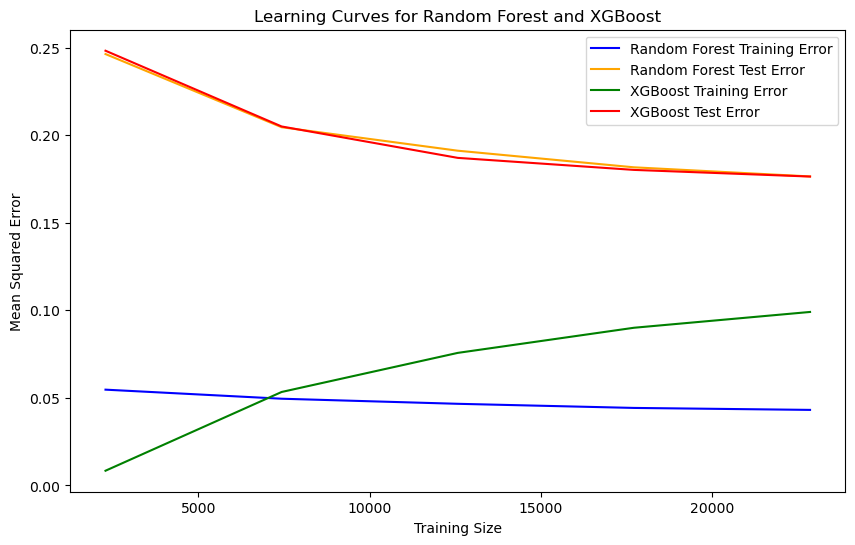

In [32]:
train_sizes, train_scores, test_scores = learning_curve(best_rf, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, -np.mean(train_scores, axis=1), label="Random Forest Training Error", color='blue')
plt.plot(train_sizes, -np.mean(test_scores, axis=1), label="Random Forest Test Error", color='orange')

train_sizes, train_scores, test_scores = learning_curve(xgb_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
plt.plot(train_sizes, -np.mean(train_scores, axis=1), label="XGBoost Training Error", color='green')
plt.plot(train_sizes, -np.mean(test_scores, axis=1), label="XGBoost Test Error", color='red')

plt.xlabel("Training Size")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curves for Random Forest and XGBoost")
plt.legend()
plt.show()

## Modelling (60:10:10)

In [33]:
X = data.drop(columns=['magnitude'])
y = data['magnitude']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [34]:
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [35]:
rf = RandomForestRegressor(random_state=42)
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, 
                               n_iter=30, cv=3, verbose=1, random_state=42, n_jobs=-1)
rf_random.fit(X_train_scaled, y_train)
best_rf = rf_random.best_estimator_

xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

y_pred_rf = best_rf.predict(X_test_scaled)
y_pred_xgb = xgb_model.predict(X_test_scaled)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


## Evaluation

In [36]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"Random Forest MSE: {mse_rf:.4f}, R2: {r2_rf:.4f}")
print(f"XGBoost MSE: {mse_xgb:.4f}, R2: {r2_xgb:.4f}")

cv_rf_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
cv_xgb_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

print(f'Cross-Validation MSE for RandomForest: {np.mean(cv_rf_scores):.4f}')
print(f'Cross-Validation MSE for XGBoost: {np.mean(cv_xgb_scores):.4f}')

Random Forest MSE: 0.1854, R2: 0.7333
XGBoost MSE: 0.1841, R2: 0.7352
Cross-Validation MSE for RandomForest: -0.1801
Cross-Validation MSE for XGBoost: -0.1782


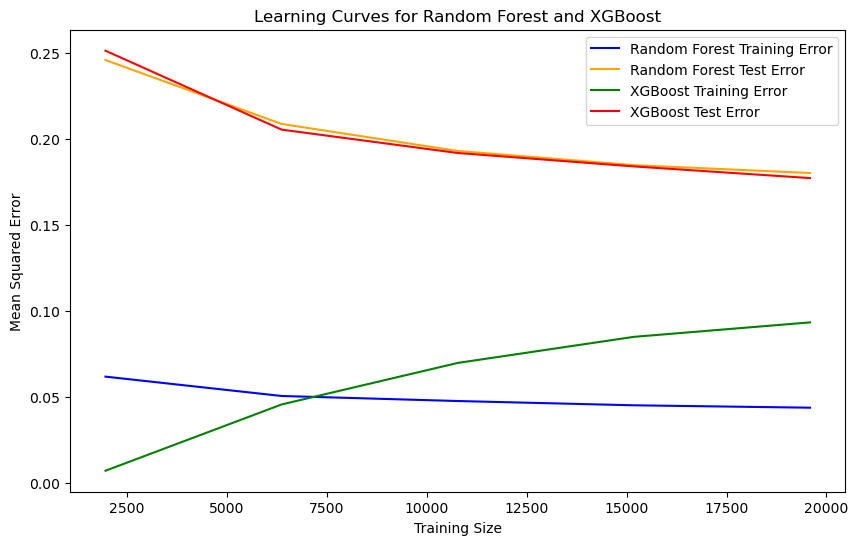

In [37]:
train_sizes, train_scores, test_scores = learning_curve(best_rf, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, -np.mean(train_scores, axis=1), label="Random Forest Training Error", color='blue')
plt.plot(train_sizes, -np.mean(test_scores, axis=1), label="Random Forest Test Error", color='orange')

train_sizes, train_scores, test_scores = learning_curve(xgb_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
plt.plot(train_sizes, -np.mean(train_scores, axis=1), label="XGBoost Training Error", color='green')
plt.plot(train_sizes, -np.mean(test_scores, axis=1), label="XGBoost Test Error", color='red')

plt.xlabel("Training Size")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curves for Random Forest and XGBoost")
plt.legend()
plt.show()

## Modelling (Menggunakan Hyperparameter Tuning)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

grid_search_rf = GridSearchCV(estimator=RandomForestRegressor(random_state=42), 
                              param_grid=param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train_scaled, y_train)
print("Best parameters for Random Forest:", grid_search_rf.best_params_)
best_rf_grid = grid_search_rf.best_estimator_

Fitting 3 folds for each of 324 candidates, totalling 972 fits


C:\Users\ricar\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

grid_search_xgb = GridSearchCV(estimator=XGBRegressor(objective='reg:squarederror', random_state=42), 
                               param_grid=param_grid_xgb, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train_scaled, y_train)
print("Best parameters for XGBoost:", grid_search_xgb.best_params_)
best_xgb_grid = grid_search_xgb.best_estimator_

In [ ]:
X = data.drop(columns=['magnitude'])
y = data['magnitude']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(0.2 / 0.3), random_state=42)

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("NaN di X_train_scaled:", np.isnan(X_train_scaled).sum())
print("Inf di X_train_scaled:", np.isinf(X_train_scaled).sum())

In [ ]:
param_dist_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42)
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_dist_rf, 
                               n_iter=30, cv=3, verbose=1, random_state=42, n_jobs=-1)
rf_random.fit(X_train_scaled, y_train)
best_rf = rf_random.best_estimator_

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_random = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist_xgb,
                                n_iter=30, cv=3, verbose=1, random_state=42, n_jobs=-1)
xgb_random.fit(X_train_scaled, y_train)
best_xgb = xgb_random.best_estimator_

y_pred_rf = best_rf.predict(X_test_scaled)
y_pred_xgb = best_xgb.predict(X_test_scaled)

## Evaluation

In [ ]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"Random Forest MSE: {mse_rf:.4f}, R2: {r2_rf:.4f}")
print(f"XGBoost MSE: {mse_xgb:.4f}, R2: {r2_xgb:.4f}")

cv_rf_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
cv_xgb_scores = cross_val_score(best_xgb, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

print(f'Cross-Validation MSE for RandomForest: {np.mean(cv_rf_scores):.4f}')
print(f'Cross-Validation MSE for XGBoost: {np.mean(cv_xgb_scores):.4f}')

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(best_rf, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, -np.mean(train_scores, axis=1), label="Random Forest Training Error", color='blue')
plt.plot(train_sizes, -np.mean(test_scores, axis=1), label="Random Forest Test Error", color='orange')

train_sizes, train_scores, test_scores = learning_curve(best_xgb, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
plt.plot(train_sizes, -np.mean(train_scores, axis=1), label="XGBoost Training Error", color='green')
plt.plot(train_sizes, -np.mean(test_scores, axis=1), label="XGBoost Test Error", color='red')

plt.xlabel("Training Size")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curves for Random Forest and XGBoost")
plt.legend()
plt.show()